# Dreamer Testing

Idea in this notebook is to implement an RSSM for use in the Dreamer V2 and V3 architectures. And then to test a simple training loop.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
from flax import nnx

from dreamer.preprocessing import get_bins, twohot_decode
from dreamer.wm import DreamerConfig, DreamerWM
from dreamer.wm.losses import dreamer_wm_loss_fn
from dreamer.wm.world_model import DreamerBatch

cfg = DreamerConfig()
dreamer = DreamerWM(cfg, rngs=nnx.Rngs(0))

In [2]:
BATCH_SIZE = 2  # num_sequences
SEQ_LENGTH = 4

# training notes - sample start index uniformly, and truncate samples which go beyond
# the end of the episode (as opposed to only sampling up to T - 50)
# beyond episode end, set the discount factor gamma -> 0

In [3]:
rngs = nnx.Rngs(0)
imgs = rngs.normal((BATCH_SIZE, SEQ_LENGTH, 64, 64, 3))
reward = rngs.normal((BATCH_SIZE, SEQ_LENGTH))
cont = rngs.binomial(1, p=0.8, shape=(BATCH_SIZE, SEQ_LENGTH))
action = rngs.normal((BATCH_SIZE, SEQ_LENGTH, 3))
is_first = jnp.zeros((BATCH_SIZE, SEQ_LENGTH), dtype=jnp.bool)
is_first = is_first.at[:, 0].set(True)
is_first = is_first.at[:, 6].set(True)

batch = DreamerBatch(
    image=imgs, reward=reward, cont=cont, prev_action=action, is_first=is_first
)

In [4]:
@nnx.value_and_grad(has_aux=True)
def loss_fn(model, batch):
    preds = model(batch)
    losses = dreamer_wm_loss_fn(preds, batch, cfg.kl_alpha)
    loss = (
        cfg.kl_beta * losses.kl_loss
        + losses.continue_loss
        + losses.reward_loss
        + losses.image_loss
    )
    return loss, losses


@nnx.jit
def train_step(model, batch, optim):
    (loss, sub_losses), grads = loss_fn(model, batch)
    optim.update(model, grads)
    return loss, sub_losses

In [5]:
lr = 8e-4
tx = optax.adamw(lr)
optim = nnx.Optimizer(dreamer, tx, wrt=nnx.Param)

losses = []
sub_losses = []
for i in range(300):
    loss, loss_components = train_step(dreamer, batch, optim)
    losses.append(loss)
    sub_losses.append(loss_components)

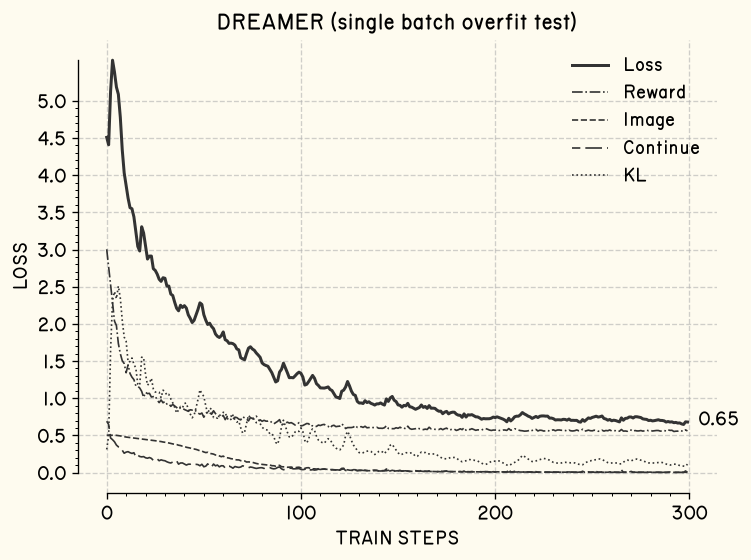

In [6]:
blk = "#333333"
off_white = "#FEFBEF"

plt.rcParams["font.family"] = "Routed Gothic"
plt.rcParams["font.style"] = "normal"
plt.rcParams["font.size"] = 11
plt.rcParams["figure.facecolor"] = off_white
plt.rcParams["axes.facecolor"] = off_white
plt.rcParams["figure.dpi"] = 120


losses = jnp.array(losses)

fig, ax = plt.subplots()
ax.plot(losses, c=blk, linewidth=1.8, label="Loss")

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_bounds(0, losses.max())
ax.spines["bottom"].set_bounds(0, len(losses))

ax.xaxis.set_ticks(jnp.arange(0, 301, 100), minor=False)
ax.xaxis.set_ticks(jnp.arange(0, 301, 10), minor=True)

ax.yaxis.set_ticks(jnp.arange(0, 5 + 0.05, 0.5), minor=False)
ax.yaxis.set_ticks(jnp.arange(0, 5, 0.1), minor=True)

ax.xaxis.set_label_text("TRAIN STEPS")
ax.yaxis.set_label_text("LOSS")

ax.annotate(f"{losses.min():.2f}", (300 + 4.5, losses[-1] - 0.045))

ax.set_title(
    "DREAMER (single batch overfit test)",
)

ax.plot(
    [sl.reward_loss for sl in sub_losses],
    c=blk,
    linewidth=1.0,
    linestyle="-.",
    label="Reward",
)
ax.plot(
    [sl.image_loss for sl in sub_losses],
    c=blk,
    linewidth=1.0,
    linestyle="--",
    label="Image",
)
ax.plot(
    [sl.continue_loss for sl in sub_losses],
    c=blk,
    linewidth=1.0,
    linestyle=(5, (10, 3)),
    label="Continue",
)
ax.plot(
    [cfg.kl_beta * sl.kl_loss for sl in sub_losses],
    c=blk,
    linewidth=1.0,
    linestyle=":",
    label="KL",
)

plt.legend(frameon=False)

plt.grid(alpha=0.6, linestyle="--")
plt.tight_layout()
plt.savefig("../assets/dummy_batch.png")
plt.show()

TODO: Write the appropriate dataloader/env interaction loop setup 
- off-by-one actions
- packing into full sequence length
- is_first bools (on the right step)
- Exponential bins...
- God there's a lot to compute yet...
- binary cross-entropy for the discount predictor (how does v3 do this? Doesn't it just predict episode end directly rather than discount? YES - "continue predictor")

TODO: Train the world model in contact with a random policy, verify that it works (and each individual component works)
TODO: Write the actor-critic implementation

In [8]:
import gymnasium as gym
import jax
from jaxtyping import Array, Float

from dreamer.buffer import (
    collect_new_rollouts,
    get_batch,
    init_buffer,
)

NUM_ENVS = 8
MAX_TIMESTEPS = 1000

envs = gym.make_vec("CarRacing-v3", num_envs=NUM_ENVS, vectorization_mode="async")

num_eps = 6
buffer_capacity = 12
buffer = init_buffer(buffer_capacity)


def random_policy(obs: Float[Array, "B H W C"], key: Array):
    minvals = jnp.array([-1, 0, 0])
    maxvals = jnp.array([1, 1, 1])
    return jax.random.uniform(
        key, shape=(obs.shape[0], 3), minval=minvals, maxval=maxvals
    )


buffer = collect_new_rollouts(
    buffer, envs, random_policy, num_eps=16, key=jax.random.key(0)
)

2026-09-23 18:31:20.915 | INFO     | dreamer.buffer:collect_new_rollouts:139 - Collecting 16 rollouts with policy 'random_policy'


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [ ]:
import mediapy as media

# OK so looks like the buffer is working ok?
batch = get_batch(buffer, 8, 50, rngs())
media.show_videos([i for i in batch.image], height=64 * 3, width=64 * 3)

In [ ]:
# # ok wait so what is my trainstep going to look like?
# from jaxtyping import Shaped

# buffer = init_buffer()
# buffer = collect_new_rollouts(random_policy)

# wm = DreamerWM
# policy = ActorCritic

# while not converged:
#     rollout = get_rollout(policy)
#     for _ in update_steps:
#         wm = wm_train_step(rollout)
#         policy = policy_train_step(rssm)


# So still todo:
#  Test that the WM trains correctly on a bigger dataset (do some imagination for comparison)
#  Reward scaling - let's look at the reward scaling. It's probably not that bad.
#  The discount/continue predictor (properly)
#  Make sure actor critic works properly (can we test on a super simple env?)
#  Is there much more to do???

In [ ]:
from dreamer.preprocessing import get_bins, symexp, symlog, twohot_decode, twohot_encode

B = get_bins()
x = jax.random.uniform(jax.random.key(4), shape=(4, 5)) * 80

encoded = twohot_encode(symlog(x), B)
decoded = symexp(twohot_decode(encoded, B))
jnp.allclose(decoded, x)

Array(True, dtype=bool)

In [ ]:
def process_reward(r: Array):
    return twohot_encode(symlog(r), B)

In [ ]:
# optax.losses.softmax_cross_entropy_with_integer_labels()

x = jax.random.uniform(jax.random.key(4), shape=(4, 5)) * 80
y = jax.random.uniform(jax.random.key(2), shape=(4, 5)) * 80

In [ ]:
y_pred_enc = twohot_encode(symlog(x), B) + 1e-8
y_enc = twohot_encode(symlog(y), B)

In [ ]:
from einops import einsum

einsum(y_enc, jnp.log(y_pred_enc), "... i, ... i -> ...")

Array([[ -1.104623  ,  -0.68361807,  -0.69003737,  -5.0196815 ,
         -0.7598511 ],
       [ -4.6669884 ,  -5.1766443 , -18.420681  ,  -0.4180981 ,
         -4.0074005 ],
       [ -6.2864275 , -16.115139  , -18.420681  ,  -0.6113484 ,
        -18.420681  ],
       [-18.420681  ,  -1.0229024 ,  -1.3623207 ,  -4.4060555 ,
        -18.420681  ]], dtype=float32)

In [ ]:
optax.losses.softmax_cross_entropy(jnp.log(y_pred_enc), y_enc)

Array([[ 1.104623  ,  0.6836182 ,  0.6900375 ,  5.0196815 ,  0.75985134],
       [ 4.6669884 ,  5.1766443 , 18.420681  ,  0.41809824,  4.007401  ],
       [ 6.2864275 , 16.115139  , 18.420681  ,  0.61134845, 18.420681  ],
       [18.420681  ,  1.0229025 ,  1.3623209 ,  4.406056  , 18.420681  ]],      dtype=float32)

In [ ]:
from dreamer.wm.world_model import DreamerWMOut


class ActorCritic(nnx.Module):
    def __init__(self, cfg: DreamerConfig, rngs: nnx.Rngs):
        # shared backbone -> actor + critic
        input_dim = cfg.latent_dim + cfg.wm_hidden_dim + cfg.action_dim

        self.backbone = nnx.Sequential(
            nnx.Linear(input_dim, cfg.agent_hidden_dim, rngs=rngs),
            cfg.activation_fn,
            nnx.Linear(cfg.agent_hidden_dim, cfg.agent_hidden_dim, rngs=rngs),
            cfg.activation_fn,
        )  # type: ignore

        self.actor_head = nnx.Linear(cfg.agent_hidden_dim, cfg.action_dim, rngs=rngs)
        self.critic_head = nnx.Linear(cfg.agent_hidden_dim, 1, rngs=rngs)

    def __call__(
        self, wm_out: DreamerWMOut, prev_action: Float[Array, "... ActionDim"]
    ) -> tuple[Array, Array]:
        z = jnp.concat([wm_out.hidden, wm_out.latent_sample, prev_action], axis=-1)
        z = self.backbone(z)

        # Predict action and squeeze into [-1:1, 0:1, 0:1]
        action_pred = self.actor_head(z)
        action_pred = nnx.sigmoid(action_pred)
        action_pred = action_pred.at[..., 0].set(action_pred[..., 0] * 2 - 1)

        value_pred = self.critic_head(z)  # idk if we need to transform this at all?

        return action_pred, value_pred

    @staticmethod
    def loss_fn(
        cfg: DreamerConfig,
        rewards: Float[Array, "B T"],
        values: Float[Array, "B T"],
    ):
        discount = cfg.discount
        lam = cfg.td_lambda

        # TODO: check if this is actually how you compute TD lambda,
        #        - I derived this sleep-derived on a 13 hour flight
        # TODO: add stopgradient
        # Compute the TD(lambda) return from the final state, summing backwards recursively
        @nnx.scan(
            in_axes=(1, 1, nnx.Carry),
            out_axes=(1, nnx.Carry),
            reverse=True,
        )
        def compute_lambda_return(r_t: Array, v_t1: Array, G_t1: Array):
            v_t1_sg = jax.lax.stop_gradient(v_t1)
            G_t = r_t + discount * ((1 - lam) * v_t1_sg + lam * G_t1)
            # first output stores the results per-timestep, the second acts as the carry
            return G_t, G_t

        carry = values[..., -1]  # take final timestep as the initial value
        target, _ = compute_lambda_return(rewards, values, carry)

        # Returned grad will be both the grad of G_t and the MSBE
        # TODO: check gradient correctness - what do I actually want for policy gradients?
        value_loss = optax.losses.squared_error(target, values)

        # policy_loss = ...

        return {
            "value_loss": value_loss,
            "target": target,
            "loss": value_loss.mean() + target.mean(),
        }

In [ ]:
# options

# Scan forwards over episode/imagination to produce trajectory (actions [B T A], values [B T])
# Scan backwards to compute TD lambda targets
# Compute gradients using TD lambda targets
ac = ActorCritic(cfg, nnx.Rngs(0))
ac.loss_fn(cfg, batch.reward, batch.reward)
# ActorCritic.loss_fn(cfg, batch.reward, batch.reward)

{'value_loss': Array([[7.5690937e-01, 7.3697132e-01, 7.1506476e-01, 6.9104040e-01,
         6.6475004e-01, 6.3605136e-01, 6.0481399e-01, 5.7092798e-01,
         5.3431463e-01, 4.9494013e-01, 4.5283440e-01, 4.0811452e-01,
         3.6101505e-01, 3.1192631e-01, 2.6144388e-01, 2.1043059e-01,
         1.6009557e-01, 1.1209362e-01, 6.8650588e-02, 3.2721192e-02,
         8.1870928e-03, 1.0552263e-04, 1.5020772e-02, 6.1354216e-02,
         1.4989215e-01, 2.9439560e-01, 5.1236171e-01, 8.2597452e-01,
         1.2632915e+00, 1.8597217e+00, 2.6598694e+00, 3.7198329e+00,
         5.1100626e+00, 2.5443020e-01, 6.3894814e-01, 6.0796267e-01,
         5.7433796e-01, 5.3799176e-01, 4.9888530e-01, 4.5704144e-01,
         4.1256744e-01, 3.6568484e-01, 3.1676698e-01, 2.6638696e-01,
         2.1537843e-01, 1.6491300e-01, 1.1659704e-01, 7.2594665e-02,
         3.5781816e-02, 9.9400897e-03],
        [9.3408912e-01, 9.3313682e-01, 9.3207610e-01, 9.3089473e-01,
         9.2957914e-01, 9.2811382e-01, 9.2648238e